## Exploratory data analysis

- missingness audit (stacked bar charts and correlation heatmap)
- z-score sanity check (histograms)
- demographic breakdown (bar charts and count plots)
- severity distributions (stacked bar charts)
- academic performance vs. mental health (violin plots)
- timeline of burnout (line plots)
- inter-condition correlations (correlation matrix heatmap)
- z-score density by source (overlapping density plots)
- departmental pressure (horizontal boxplots)
- multivariate density comparison of conditions (corner pairplot)

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

from utils import style_pct

### global constants

In [4]:
# assume notebook is run from proj_root/mhp/
ROOT = Path.cwd().parent
DATA = ROOT / "mhp" / "data"
PLOTS = ROOT / "mhp" / "plots"

Z_SCORE_COLS = ["stress_z_score", "anxiety_z_score", "depression_z_score"]
SEVERITY_COLS = ["stress_level", "anxiety_level", "depression_level"]
DEMOGRAPHIC_COLS = ["age", "gender", "academic_year", "cgpa"]

PLACEHOLDER_LABELS = ["other", "unknown", "not_recorded"]
SEVERITY_ORDER = [
    "none",
    "minimal",
    "mild",
    "moderate",
    "moderately_severe",
    "severe",
]

CLEAN_LABELS = {
    "age": "Age",
    "gender": "Gender",
    "academic_year": "Academic Year",
    "cgpa": "CGPA",
    "stress_z_score": "Stress (Z-Score)",
    "anxiety_z_score": "Anxiety (Z-Score)",
    "depression_z_score": "Depression (Z-Score)",
    "stress_level": "Stress (Level)",
    "anxiety_level": "Anxiety (Level)",
    "depression_level": "Depression (Level)",
    "dataset1": "Primary Dataset",
    "dataset2": "Secondary Dataset",
}

# color scheme
COLOR_PRIMARY = "steelblue"
COLOR_SECONDARY = "sandybrown"
COLOR_NEUTRAL = "lightgray"
CMAP_DIVERGING = "vlag"
CMAP_SEQUENTIAL = "mako"

MISSINGNESS_PALETTE = {
    "NA": "indianred",
    "other": "steelblue",
    "unknown": "sandybrown",
    "not_recorded": "gray",
}

In [5]:
mhp_dataset = pd.read_parquet(DATA / "mhp_dataset.parquet")

### missingness audit

Columns with missing values:


,n_missing,pct_missing
anxiety_level,8,0.34%
anxiety_z_score,8,0.34%


Sentinel categories summary


,column,level,n,pct
0,department,not_recorded,351,14.75%
1,cgpa,other,181,7.61%
2,academic_year,other,147,6.18%
3,department,other,79,3.32%
4,gender,other,10,0.42%
5,academic_year,unknown,5,0.21%


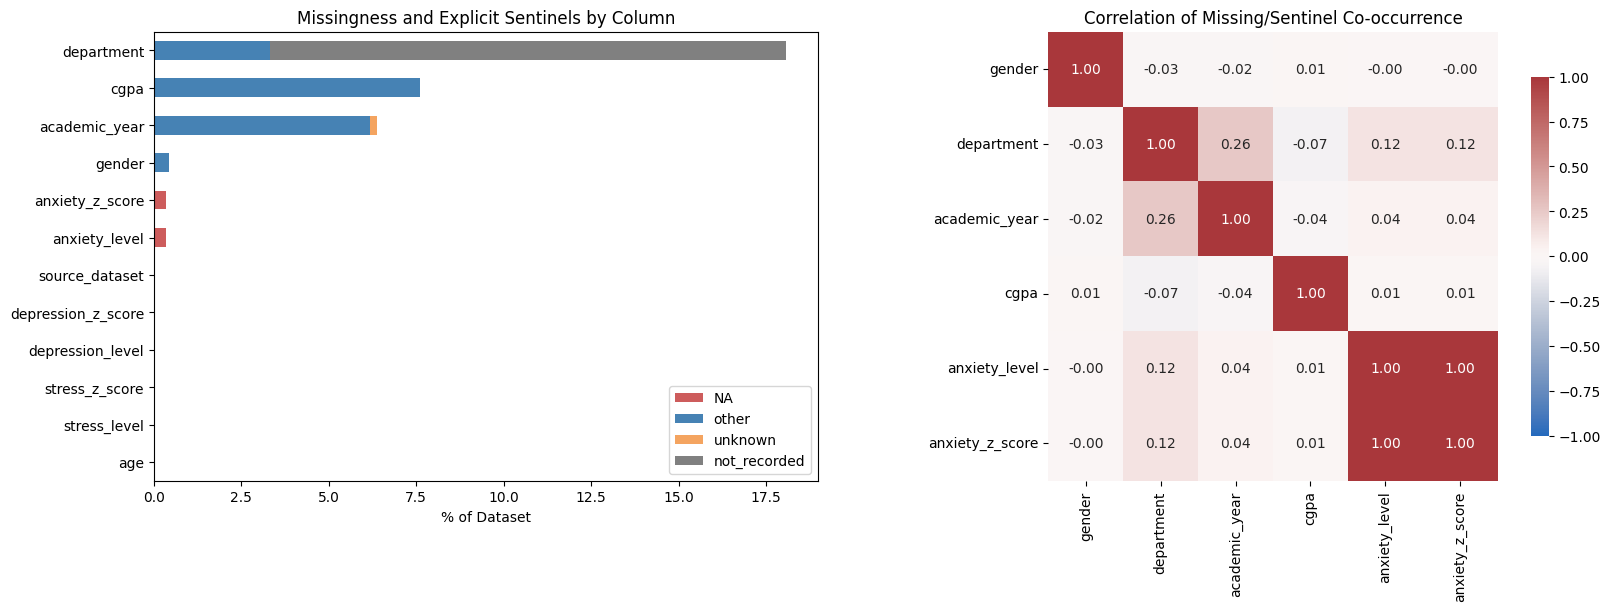

In [6]:
n = len(mhp_dataset)
na_counts = mhp_dataset.isna().sum()
na_pct = (na_counts / n) * 100

if na_counts.sum() > 0:
    print("Columns with missing values:")
    na_df = pd.DataFrame(
        {"n_missing": na_counts, "pct_missing": (na_counts / n) * 100}
    )
    na_df = na_df[na_df["n_missing"] > 0].sort_values("n_missing")
    display(style_pct(na_df))

sentinel_rows = []
for col in mhp_dataset.columns:
    for label in PLACEHOLDER_LABELS:
        count = mhp_dataset[col].isin([label]).sum()
        if count > 0:
            sentinel_rows.append(
                {
                    "column": col,
                    "level": label,
                    "n": count,
                    "pct": (count / n) * 100,
                }
            )

if sentinel_rows:
    print("Sentinel categories summary")
    sentinel_tbl = pd.DataFrame(sentinel_rows).sort_values(
        ["pct", "level"], ascending=False, ignore_index=True
    )
    display(style_pct(sentinel_tbl))


stack_components = pd.DataFrame(index=mhp_dataset.columns)
stack_components["NA"] = na_pct
for label in PLACEHOLDER_LABELS:
    stack_components[label] = (mhp_dataset.isin([label]).sum() / n) * 100

cols_order = stack_components.sum(axis=1).sort_values(ascending=True).index
stack_plot = stack_components.loc[cols_order]

fig, (ax_bar, ax_heat) = plt.subplots(
    1, 2, figsize=(16, 6), constrained_layout=True
)

stack_plot.plot(kind="barh", stacked=True, color=MISSINGNESS_PALETTE, ax=ax_bar)

ax_bar.set_xlabel("% of Dataset")
ax_bar.set_title("Missingness and Explicit Sentinels by Column")
ax_bar.legend(loc="lower right")

combined_mask = mhp_dataset.isna() | mhp_dataset.isin(PLACEHOLDER_LABELS)
varied_cols = [
    col for col in combined_mask.columns if combined_mask[col].var() > 0
]
correlation_matrix = combined_mask[varied_cols].corr()

sns.heatmap(
    correlation_matrix,
    ax=ax_heat,
    cmap=CMAP_DIVERGING,
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    annot=True,
    fmt=".2f",
    cbar_kws={"shrink": 0.8},
)
ax_heat.set_title("Correlation of Missing/Sentinel Co-occurrence")

plt.show()

In [7]:
fig.savefig(PLOTS / "missingness_audit.svg", format="svg", bbox_inches="tight")

### z-score sanity check

Z-score summary (expect mean ~0 and std ~1):


,count,mean,std,min,max
stress_z_score,2379,-0.000,1.000,-3.405,3.197
anxiety_z_score,2371,0.000,1.000,-2.247,3.061
depression_z_score,2379,-0.000,1.000,-2.164,3.195


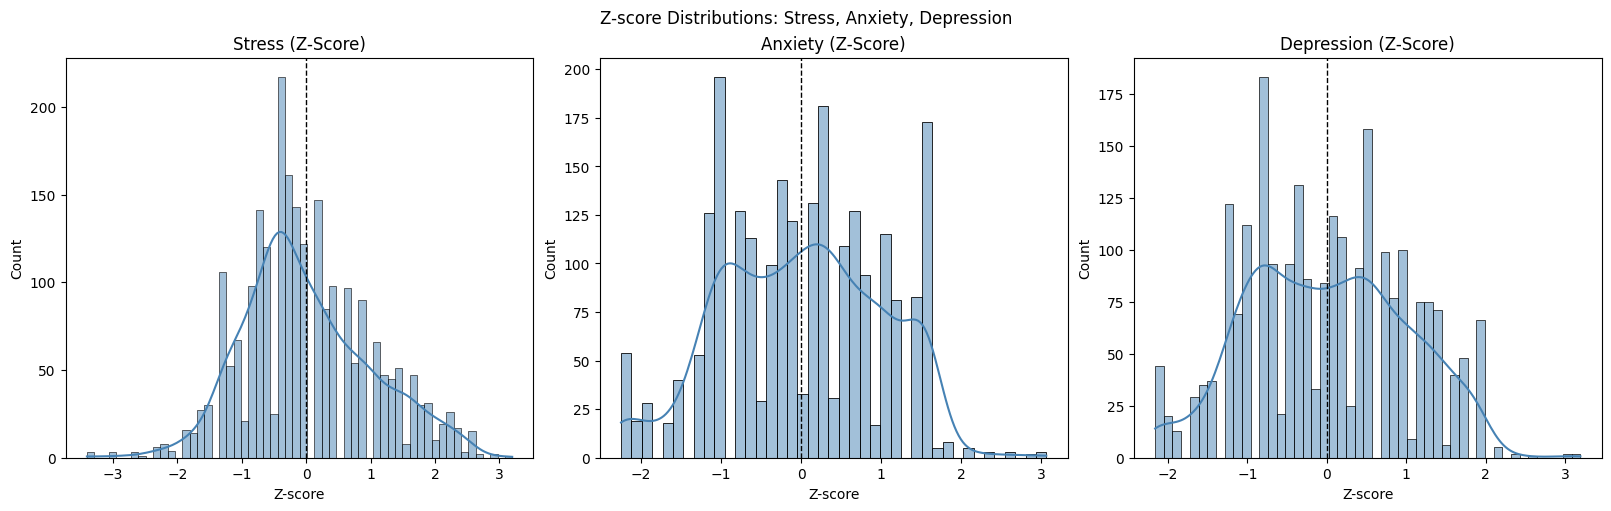

In [8]:
z_summary = (
    mhp_dataset[Z_SCORE_COLS].agg(["count", "mean", "std", "min", "max"]).T
)
print("Z-score summary (expect mean ~0 and std ~1):")
display(
    z_summary.style.format("{:.0f}", subset=["count"]).format(
        "{:.3f}", subset=["mean", "std", "min", "max"]
    )
)

fig, axes = plt.subplots(
    1, len(Z_SCORE_COLS), figsize=(16, 5), constrained_layout=True
)

for ax, col in zip(axes, Z_SCORE_COLS):
    unique_vals = mhp_dataset[col].nunique()

    sns.histplot(
        mhp_dataset[col].dropna(),
        bins=unique_vals,
        kde=True,
        ax=ax,
        color=COLOR_PRIMARY,
    )

    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(CLEAN_LABELS[col])
    ax.set_xlabel("Z-score")
    ax.set_ylabel("Count")

fig.suptitle("Z-score Distributions: Stress, Anxiety, Depression")
plt.show()

In [9]:
fig.savefig(
    PLOTS / "z_score_distributions.svg", format="svg", bbox_inches="tight"
)

### demographic breakdown


Demographic Frequency Tables:


,age,count,pct
0,18-22,1514,63.64%
1,23-26,830,34.89%
2,27-30,28,1.18%
3,<18,4,0.17%
4,>30,3,0.13%


,gender,count,pct
0,male,1616,67.93%
1,female,753,31.65%
2,other,10,0.42%


,academic_year,count,pct
0,third,684,28.75%
1,first,654,27.49%
2,fourth,459,19.29%
3,second,430,18.07%
4,other,147,6.18%
5,unknown,5,0.21%


,cgpa,count,pct
0,3.00-3.39,696,29.26%
1,3.40-3.79,664,27.91%
2,2.50-2.99,460,19.34%
3,3.80-4.00,283,11.90%
4,other,181,7.61%
5,<2.50,95,3.99%


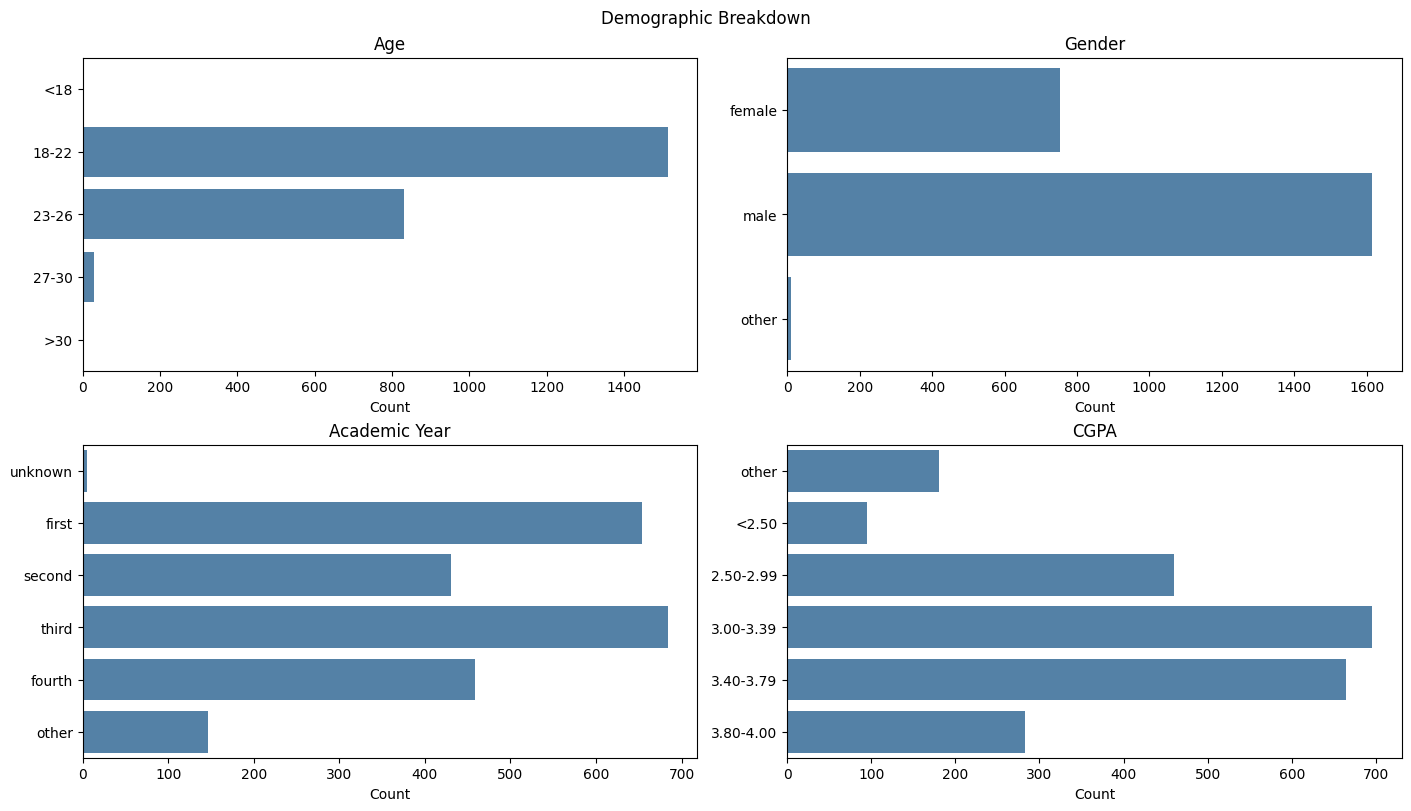

In [10]:
print("Demographic Frequency Tables:")
for col in DEMOGRAPHIC_COLS:
    freq = (
        mhp_dataset[col]
        .value_counts()
        .rename_axis(col)
        .reset_index(name="count")
    )
    freq["pct"] = (freq["count"] / len(mhp_dataset)) * 100
    display(style_pct(freq))

fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)
axes = axes.flatten()

for ax, col in zip(axes, DEMOGRAPHIC_COLS):
    is_categorical = isinstance(mhp_dataset[col].dtype, pd.CategoricalDtype)
    plot_order = (
        None if is_categorical else mhp_dataset[col].value_counts().index
    )

    sns.countplot(
        data=mhp_dataset, y=col, order=plot_order, ax=ax, color=COLOR_PRIMARY
    )
    ax.set_title(CLEAN_LABELS[col])
    ax.set_xlabel("Count")
    ax.set_ylabel("")

fig.suptitle("Demographic Breakdown")
plt.show()

In [11]:
fig.savefig(
    PLOTS / "demographic_breakdown.svg", format="svg", bbox_inches="tight"
)

### severity distributions

Severity Distribution by Condition:


,None,Minimal,Mild,Moderate,Moderately Severe,Severe
Stress (Level),2.56%,12.99%,1.77%,57.92%,0.80%,23.96%
Anxiety (Level),2.66%,9.91%,22.48%,30.03%,1.48%,33.45%
Depression (Level),4.71%,7.94%,19.71%,22.57%,22.57%,22.49%


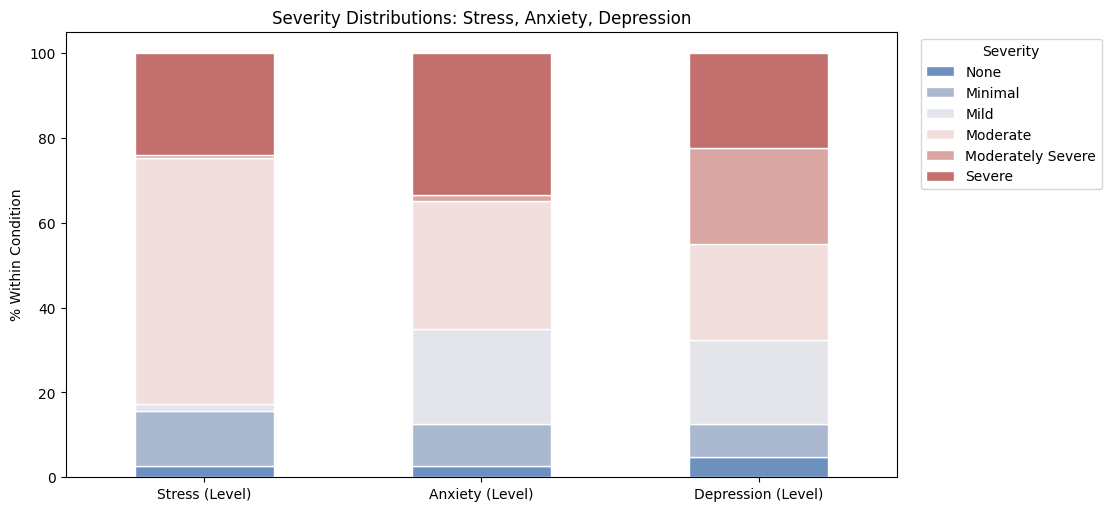

In [12]:
severity_tbl = (
    mhp_dataset[SEVERITY_COLS].apply(lambda x: x.value_counts(normalize=True)).T
    * 100
).reindex(columns=SEVERITY_ORDER)

severity_tbl = severity_tbl.rename(
    index=CLEAN_LABELS, columns=lambda x: x.replace("_", " ").title()
)
print("Severity Distribution by Condition:")
display(style_pct(severity_tbl, "all"))

fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)

severity_tbl.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=sns.color_palette(CMAP_DIVERGING, len(SEVERITY_ORDER)),
    edgecolor="white",
)

ax.set_title("Severity Distributions: Stress, Anxiety, Depression")
ax.set_xlabel("")
ax.set_ylabel("% Within Condition")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Severity", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.show()

In [13]:
fig.savefig(
    PLOTS / "severity_distributions.svg", format="svg", bbox_inches="tight"
)

### academic performance vs. mental health

Mental Health Z-Score Summary by CGPA Band:


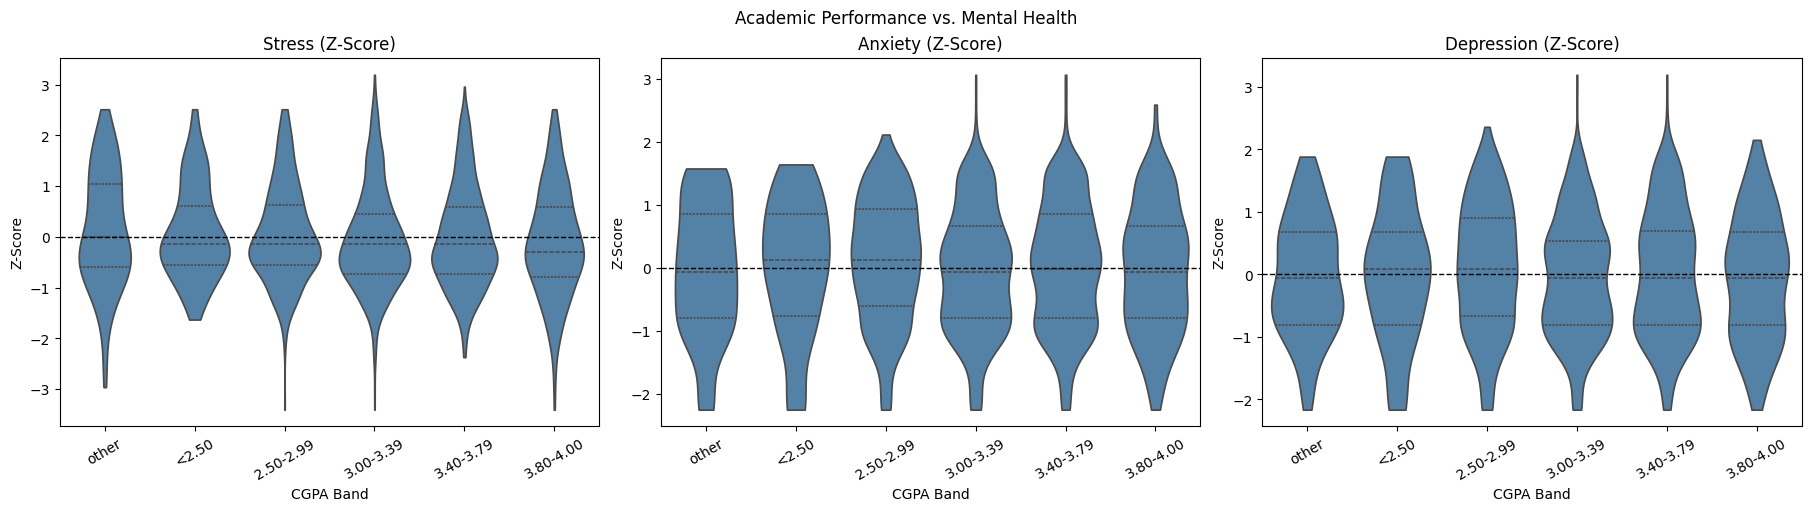

In [14]:
cgpa_summary = mhp_dataset.groupby("cgpa", observed=True)[Z_SCORE_COLS].agg(
    ["count", "mean", "median"]
)

print("Mental Health Z-Score Summary by CGPA Band:")
display(cgpa_summary.style.format(precision=3))

fig, axes = plt.subplots(
    1, len(Z_SCORE_COLS), figsize=(18, 5), constrained_layout=True
)

for ax, col in zip(axes, Z_SCORE_COLS):
    sns.violinplot(
        data=mhp_dataset,
        x="cgpa",
        y=col,
        ax=ax,
        color=COLOR_PRIMARY,
        inner="quartile",
        cut=0,
    )

    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(CLEAN_LABELS[col])
    ax.set_xlabel("CGPA Band")
    ax.set_ylabel("Z-Score")
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("Academic Performance vs. Mental Health")
plt.show()

In [15]:
fig.savefig(PLOTS / "cgpa_vs_mhp.svg", format="svg", bbox_inches="tight")

### timeline of burnout

Mental Health Z-Score Summary by Academic Year:


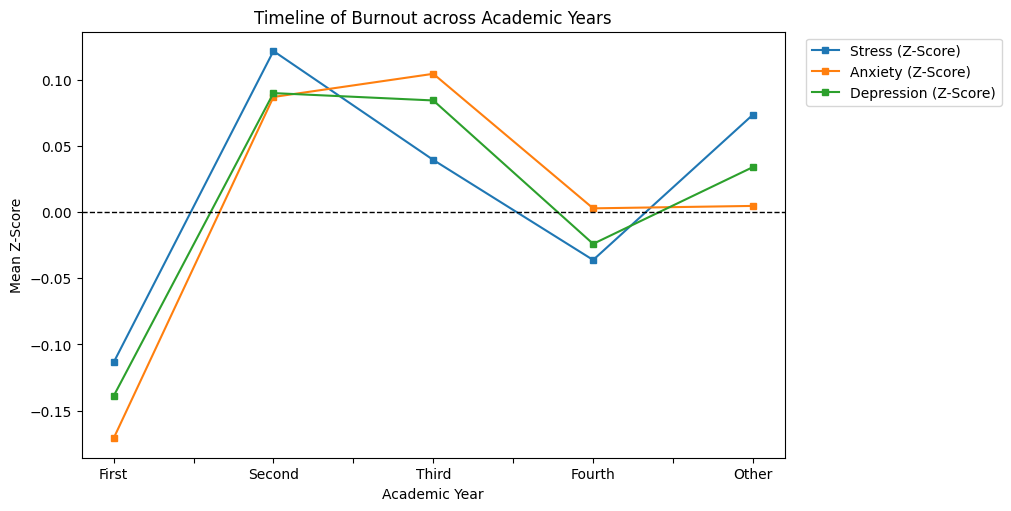

In [16]:
year_summary = mhp_dataset.groupby("academic_year", observed=True)[
    Z_SCORE_COLS
].agg(["count", "mean", "median"])
print("Mental Health Z-Score Summary by Academic Year:")
display(year_summary.style.format(precision=3))

timeline_data = mhp_dataset[mhp_dataset["academic_year"] != "unknown"].copy()
timeline_mean = timeline_data.groupby("academic_year", observed=True)[
    Z_SCORE_COLS
].mean()

timeline_mean = timeline_mean.rename(
    index=lambda x: str(x).title(), columns=CLEAN_LABELS
)

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)

timeline_mean.plot(kind="line", marker="s", markersize=5, ax=ax)

ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Timeline of Burnout across Academic Years")
ax.set_xlabel("Academic Year")
ax.set_ylabel("Mean Z-Score")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.show()

In [17]:
fig.savefig(
    PLOTS / "timeline_of_burnout.svg", format="svg", bbox_inches="tight"
)

### inter-condition correlations

Inter-Condition Correlations (Pearson):


,stress_z_score,anxiety_z_score,depression_z_score
stress_z_score,1.000,0.667,0.616
anxiety_z_score,0.667,1.000,0.771
depression_z_score,0.616,0.771,1.000


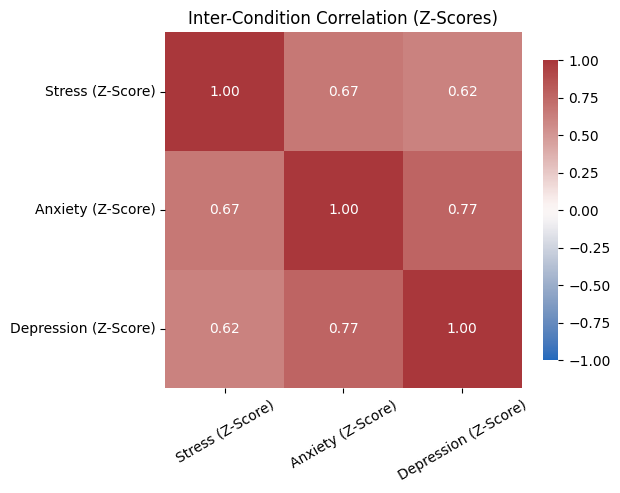

In [18]:
corr_matrix = mhp_dataset[Z_SCORE_COLS].corr()
print("Inter-Condition Correlations (Pearson):")
display(corr_matrix.style.format(precision=3))

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)

sns.heatmap(
    corr_matrix,
    ax=ax,
    cmap=CMAP_DIVERGING,
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    square=True,
    cbar_kws={"shrink": 0.8},
    xticklabels=[CLEAN_LABELS[col] for col in corr_matrix.columns],
    yticklabels=[CLEAN_LABELS[col] for col in corr_matrix.index],
)

ax.set_title("Inter-Condition Correlation (Z-Scores)")
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)

plt.show()

In [19]:
fig.savefig(
    PLOTS / "inter_condition_correlations.svg",
    format="svg",
    bbox_inches="tight",
)

### z-score density by source

Z-Score Summary by Source Dataset:


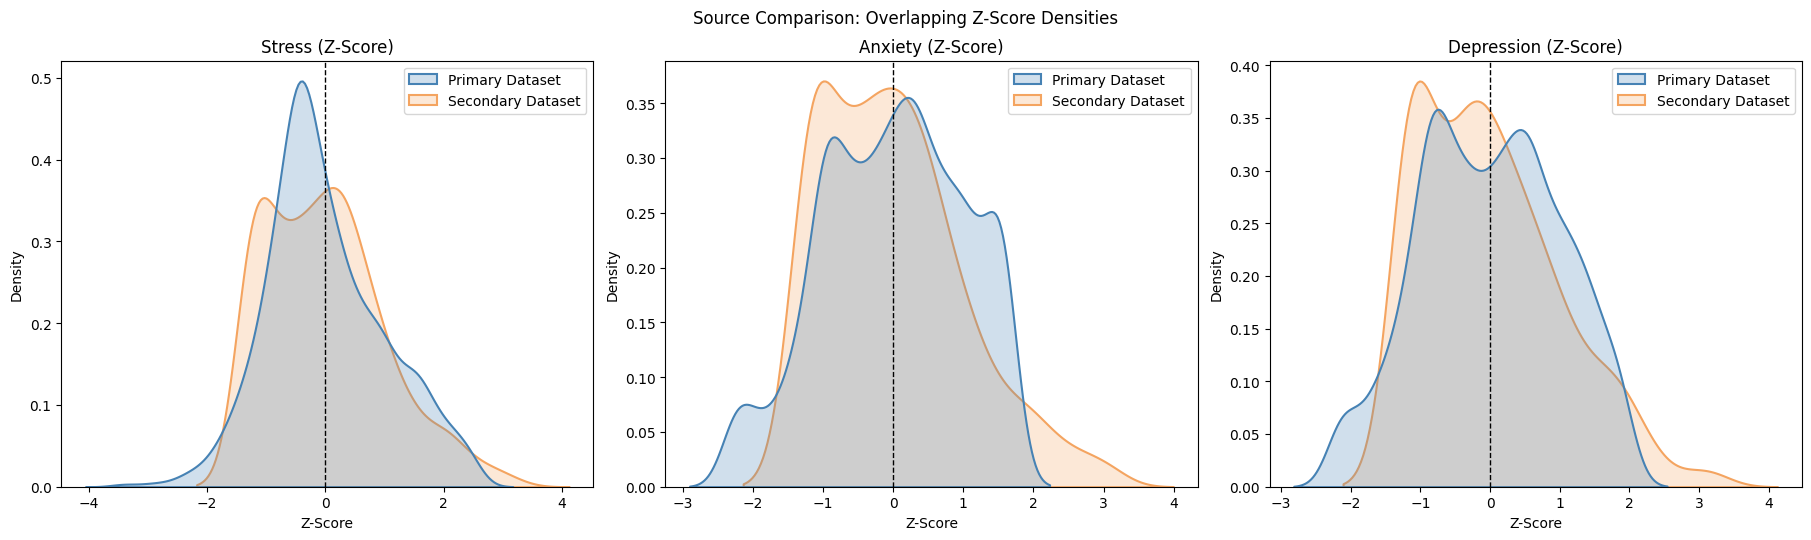

In [20]:
source_summary = mhp_dataset.groupby("source_dataset", observed=True)[
    Z_SCORE_COLS
].agg(["count", "mean", "std", "median"])

print("Z-Score Summary by Source Dataset:")
display(
    source_summary.style.format(
        "{:.0f}", subset=pd.IndexSlice[:, pd.IndexSlice[:, "count"]]
    ).format(
        "{:.3f}",
        subset=pd.IndexSlice[:, pd.IndexSlice[:, ["mean", "std", "median"]]],
    )
)

fig, axes = plt.subplots(
    1, len(Z_SCORE_COLS), figsize=(18, 5), constrained_layout=True
)

for ax, col in zip(axes, Z_SCORE_COLS):
    sns.kdeplot(
        data=mhp_dataset,
        x=col,
        hue="source_dataset",
        common_norm=False,
        fill=True,
        alpha=0.25,
        linewidth=1.5,
        ax=ax,
        palette=[COLOR_PRIMARY, COLOR_SECONDARY],
    )
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(CLEAN_LABELS[col])
    ax.set_xlabel("Z-Score")
    ax.set_ylabel("Density")

    if ax.get_legend():
        ax.get_legend().set_title("")
        for text in ax.get_legend().get_texts():
            text.set_text(CLEAN_LABELS[text.get_text()])

fig.suptitle("Source Comparison: Overlapping Z-Score Densities", y=1.05)
plt.show()

In [21]:
fig.savefig(
    PLOTS / "z_score_density_by_source.svg", format="svg", bbox_inches="tight"
)

### departmental pressure

Department-Level Z-Score Summary:


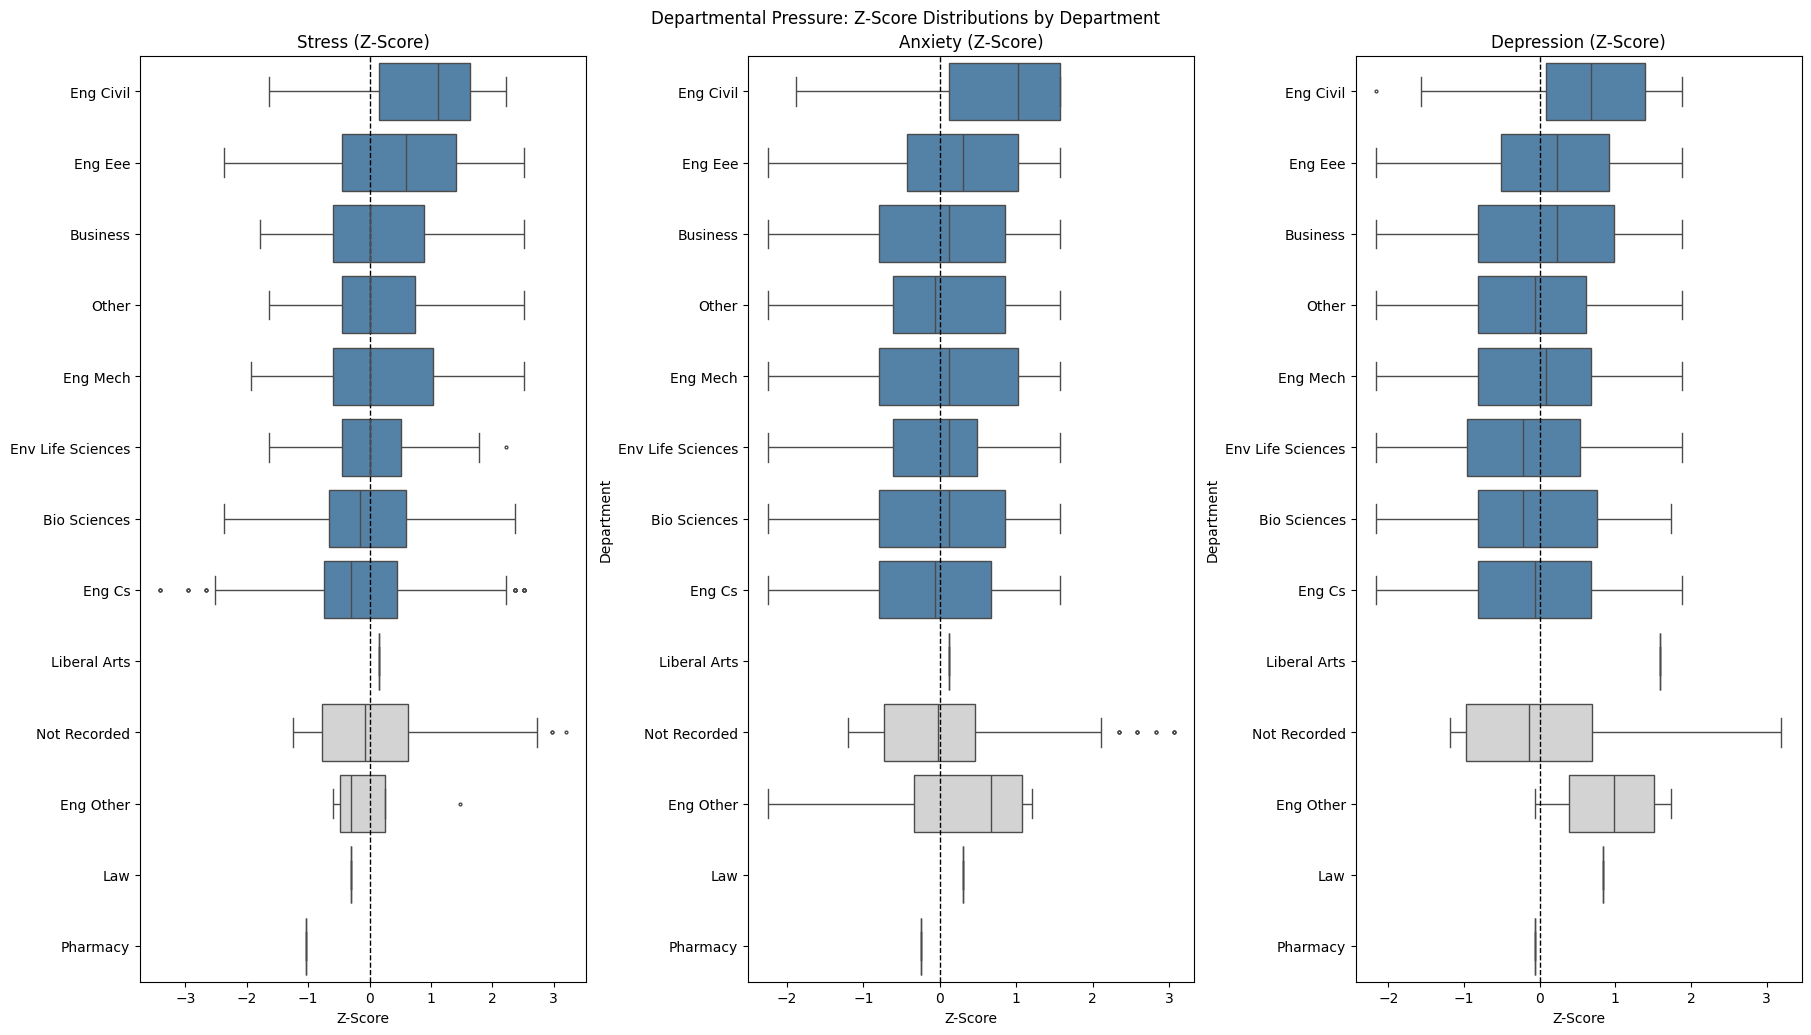

In [22]:
mhp_plot = mhp_dataset.copy()
mhp_plot["department"] = (
    mhp_plot["department"].str.replace("_", " ").str.title()
)

counts = mhp_plot["department"].value_counts()
valid_depts = [
    dept for dept in counts[counts >= 20].index if dept != "Not Recorded"
]
invalid_depts = [
    dept for dept in mhp_plot["department"].unique() if dept not in valid_depts
]

dept_summary = mhp_plot.groupby("department", observed=True)[Z_SCORE_COLS].agg(
    ["count", "mean", "median"]
)
print("Department-Level Z-Score Summary:")
display(
    dept_summary.style.format(
        "{:.0f}", subset=pd.IndexSlice[:, pd.IndexSlice[:, "count"]]
    ).format(
        "{:.3f}", subset=pd.IndexSlice[:, pd.IndexSlice[:, ["mean", "median"]]]
    )
)

stress_medians = mhp_plot.groupby("department", observed=True)[
    "stress_z_score"
].median()
valid_ordered = (
    stress_medians[valid_depts].sort_values(ascending=False).index.tolist()
)
invalid_ordered = (
    stress_medians[invalid_depts].sort_values(ascending=False).index.tolist()
)
full_order = valid_ordered + invalid_ordered

color_map = {
    dept: COLOR_PRIMARY if dept in valid_depts else COLOR_NEUTRAL
    for dept in full_order
}

fig, axes = plt.subplots(
    1, len(Z_SCORE_COLS), figsize=(18, 10), constrained_layout=True
)

for ax, col in zip(axes, Z_SCORE_COLS):
    sns.boxplot(
        data=mhp_plot,
        y="department",
        x=col,
        order=full_order,
        orient="h",
        ax=ax,
        hue="department",
        palette=color_map,
        fliersize=2,
        dodge=False,
        legend=False,
    )

    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(CLEAN_LABELS[col])
    ax.set_xlabel("Z-Score")
    ax.set_ylabel("Department" if col != Z_SCORE_COLS[0] else "")

fig.suptitle(
    "Departmental Pressure: Z-Score Distributions by Department", y=1.02
)
plt.show()

In [23]:
fig.savefig(
    PLOTS / "departmental_pressure.svg", format="svg", bbox_inches="tight"
)

### multivariate density comparison of conditions

Pairplot sample size: 2371


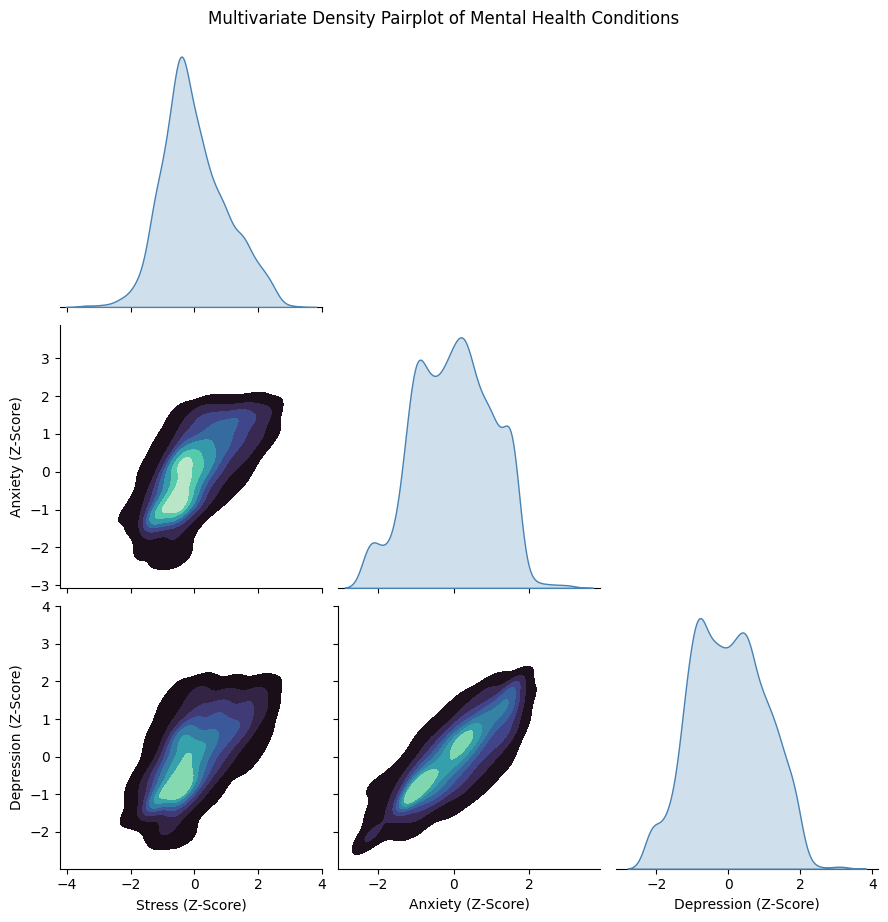

In [24]:
pair_df = mhp_dataset[Z_SCORE_COLS].dropna().rename(columns=CLEAN_LABELS)
print(f"Pairplot sample size: {len(pair_df)}")

g = sns.pairplot(
    pair_df,
    kind="kde",
    diag_kind="kde",
    corner=True,
    height=3,
    plot_kws={
        "fill": True,
        "levels": 8,
        "thresh": 0.05,
        "cmap": CMAP_SEQUENTIAL,
    },
    diag_kws={"fill": True, "color": COLOR_PRIMARY},
)
g.figure.suptitle(
    "Multivariate Density Pairplot of Mental Health Conditions", y=1.02
)
plt.show()

In [25]:
g.figure.savefig(
    PLOTS / "conditions_density_pairplot.svg", format="svg", bbox_inches="tight"
)